# Flagging Vendor Invoices for Manual Review 

## Objective:

Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce
financial risk, improve operational efficiency, and priortize human review where it adds the most value.

- Manual invoice review is time-consuming and does not upscale with transaction volume.
- Abnormal freight charges, pricing deviaitons, or delivery delays often indicate errors, disputes, or compliance risks.
- An automated flagging system enables finance teams to focus attention to high-risk invoices while allowing low-risk invoices to be processed automatically.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

In [8]:
purchase_df = pd.read_csv(r"C:\Users\dell\Invoice ML Project\data\purchases.csv")

purchase_df.head()

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


In [11]:
# Exploring the dataset furthermore:

purchase_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2372474 entries, 0 to 2372473
Data columns (total 16 columns):
 #   Column          Dtype         
---  ------          -----         
 0   InventoryId     object        
 1   Store           int64         
 2   Brand           int64         
 3   Description     object        
 4   Size            object        
 5   VendorNumber    int64         
 6   VendorName      object        
 7   PONumber        int64         
 8   PODate          datetime64[ns]
 9   ReceivingDate   datetime64[ns]
 10  InvoiceDate     object        
 11  PayDate         object        
 12  PurchasePrice   float64       
 13  Quantity        int64         
 14  Dollars         float64       
 15  Classification  int64         
dtypes: datetime64[ns](2), float64(2), int64(6), object(6)
memory usage: 289.6+ MB


In [12]:
purchase_df.describe()

,Store,Brand,VendorNumber,PONumber,PODate,ReceivingDate,PurchasePrice,Quantity,Dollars,Classification
count,2.372474e+06,2.372474e+06,2.372474e+06,2.372474e+06,2372474,2372474,2.372474e+06,2.372474e+06,2.372474e+06,2.372474e+06
mean,4.465133e+01,1.241864e+04,6.886436e+03,1.104094e+04,2024-07-04 13:34:14.973836800,2024-07-12 04:28:06.818400768,1.205005e+01,1.415585e+01,1.356815e+02,1.443520e+00
min,1.000000e+00,5.800000e+01,2.000000e+00,8.106000e+03,2023-12-20 00:00:00,2024-01-01 00:00:00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00
25%,2.500000e+01,3.639000e+03,3.252000e+03,9.761000e+03,2024-04-12 00:00:00,2024-04-20 00:00:00,6.120000e+00,6.000000e+00,4.926000e+01,1.000000e+00
50%,4.800000e+01,6.523000e+03,4.425000e+03,1.110300e+04,2024-07-07 00:00:00,2024-07-15 00:00:00,9.220000e+00,1.000000e+01,8.393000e+01,1.000000e+00
75%,6.700000e+01,1.887700e+04,9.552000e+03,1.239700e+04,2024-09-30 00:00:00,2024-10-07 00:00:00,1.449000e+01,1.200000e+01,1.405200e+02,2.000000e+00
max,8.100000e+01,9.063100e+04,2.013590e+05,1.366100e+04,2024-12-23 00:00:00,2024-12-31 00:00:00,5.681810e+03,3.816000e+03,5.017570e+04,2.000000e+00
std,2.351245e+01,1.255728e+04,8.066694e+03,1.565340e+03,NaN,NaN,1.794510e+01,2.344616e+01,2.816649e+02,4.967999e-01


In [ ]:
#checking for nulll values:

purchase_df = [u

In [ ]:
select 

vi.Quantity as invoice_quantity,
vi.Dollars as invoice_dollars,
vi.freight,
(julianday(vi.InvoiecDate) - julianday(vi.PODate)) as days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) as days_to_pay,
from vendor_invoice as vi


In [10]:
# Changing the date format for dates:

purchase_df['ReceivingDate'] = pd.to_datetime(purchase_df['ReceivingDate'])
purchase_df['PODate'] = pd.to_datetime(purchase_df['PODate'])


purchase_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2372474 entries, 0 to 2372473
Data columns (total 16 columns):
 #   Column          Dtype         
---  ------          -----         
 0   InventoryId     object        
 1   Store           int64         
 2   Brand           int64         
 3   Description     object        
 4   Size            object        
 5   VendorNumber    int64         
 6   VendorName      object        
 7   PONumber        int64         
 8   PODate          datetime64[ns]
 9   ReceivingDate   datetime64[ns]
 10  InvoiceDate     object        
 11  PayDate         object        
 12  PurchasePrice   float64       
 13  Quantity        int64         
 14  Dollars         float64       
 15  Classification  int64         
dtypes: datetime64[ns](2), float64(2), int64(6), object(6)
memory usage: 289.6+ MB


In [15]:
# Calculating Receiving delay in Days:

purchase_df['ReceivingDelay'] = (purchase_df['ReceivingDate'] - purchase_df['PODate']).dt.days

purchase_df.sample(5)


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification,ReceivingDelay
130183,62_KILMARNOCK_27461,62,27461,Ecco Domani Pnt Grigio Venez,750mL,3252,E & J GALLO WINERY,8537,2024-01-19,2024-01-25,2024-02-07,2024-03-08,6.12,11,67.32,2,6
1180374,38_GOULCREST_9037,38,9037,Prairie Organic Cucumber Vod,750mL,9206,PHILLIPS PRODUCTS CO.,11116,2024-07-08,2024-07-12,2024-07-21,2024-08-29,11.93,6,71.58,1,4
372166,18_FURNESS_34904,18,34904,Smoking Loon Chard,750mL,9552,M S WALKER INC,9119,2024-02-28,2024-03-11,2024-03-16,2024-04-21,4.68,12,56.16,2,12
360421,66_EANVERNESS_1384,66,1384,Bulleit 95 Rye,750mL,3960,DIAGEO NORTH AMERICA INC,9199,2024-03-04,2024-03-07,2024-03-21,2024-04-29,18.93,11,208.23,1,3
2325389,63_SWORDBREAK_4262,63,4262,Capt Morgan Spiced Rum,750mL,3960,DIAGEO NORTH AMERICA INC,13597,2024-12-20,2024-12-27,2025-01-10,2025-02-08,11.19,8,89.52,1,7


In [19]:

# group by PONumber and aggregate
purchase_agg_df = purchase_df.groupby('PONumber').agg(
    total_brands=('Brand', 'nunique'),
    total_item_quantity=('Quantity', 'sum'),
    total_item_dollars=('Dollars', 'sum'),
    avg_receiving_delay=('ReceivingDelay', 'mean')
).reset_index()

In [20]:
purchase_agg_df.head()

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271


In [21]:
purchase_agg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5543 entries, 0 to 5542
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PONumber             5543 non-null   int64  
 1   total_brands         5543 non-null   int64  
 2   total_item_quantity  5543 non-null   int64  
 3   total_item_dollars   5543 non-null   float64
 4   avg_receiving_delay  5543 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 216.7 KB


In [22]:
# Loading invoice data table:

vendor_invoice_df = pd.read_csv(r"C:\Users\dell\Invoice ML Project\data\vendor_invoice.csv")
vendor_invoice_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN


In [27]:
# Exploring the dataset furthermore:

vendor_invoice_df.isnull().sum()

VendorNumber       0
VendorName         0
InvoiceDate        0
PONumber           0
PODate             0
PayDate            0
Quantity           0
Dollars            0
Freight            0
Approval        5169
dtype: int64

In [24]:
vendor_invoice_df.describe()

,VendorNumber,PONumber,Quantity,Dollars,Freight
count,5543.00000,5543.000000,5543.000000,5.543000e+03,5543.000000
mean,20662.75212,10889.419087,6058.880931,5.807338e+04,295.954301
std,34582.15841,1600.859969,14453.338164,1.402340e+05,713.585093
min,2.00000,8106.000000,1.000000,4.140000e+00,0.020000
25%,3089.00000,9503.500000,83.000000,9.678100e+02,5.020000
50%,7240.00000,10890.000000,423.000000,4.765450e+03,24.730000
75%,10754.00000,12275.500000,5100.500000,4.458718e+04,229.660000
max,201359.00000,13661.000000,141660.000000,1.660436e+06,8468.220000


In [26]:
# Checking for null values:

vendor_invoice_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5543 entries, 0 to 5542
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   VendorNumber  5543 non-null   int64  
 1   VendorName    5543 non-null   object 
 2   InvoiceDate   5543 non-null   object 
 3   PONumber      5543 non-null   int64  
 4   PODate        5543 non-null   object 
 5   PayDate       5543 non-null   object 
 6   Quantity      5543 non-null   int64  
 7   Dollars       5543 non-null   float64
 8   Freight       5543 non-null   float64
 9   Approval      374 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 433.2+ KB


In [28]:
# Converting datatypes in correct date format:

vendor_invoice_df['InvoiceDate'] = pd.to_datetime(vendor_invoice_df['InvoiceDate'])
vendor_invoice_df['PODate'] = pd.to_datetime(vendor_invoice_df['PODate'])
vendor_invoice_df['PayDate'] = pd.to_datetime(vendor_invoice_df['PayDate'])

vendor_invoice_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5543 entries, 0 to 5542
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   VendorNumber  5543 non-null   int64         
 1   VendorName    5543 non-null   object        
 2   InvoiceDate   5543 non-null   datetime64[ns]
 3   PONumber      5543 non-null   int64         
 4   PODate        5543 non-null   datetime64[ns]
 5   PayDate       5543 non-null   datetime64[ns]
 6   Quantity      5543 non-null   int64         
 7   Dollars       5543 non-null   float64       
 8   Freight       5543 non-null   float64       
 9   Approval      374 non-null    object        
dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 433.2+ KB


In [32]:
# Feature Engineering (creating calculated columns):

vendor_invoice_df['days_to_po_invoice'] = (
    vendor_invoice_df['InvoiceDate'] - vendor_invoice_df['PODate']
).dt.days

vendor_invoice_df.sample(5)

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,days_to_po_invoice
5421,9165,ULTRA BEVERAGE COMPANY LLP,2025-01-03,13496,2024-12-13,2025-01-27,20854,275414.91,1404.62,Frank Delahunt,21
3464,6359,OLE SMOKY DISTILLERY LLC,2024-08-28,11533,2024-08-07,2024-09-24,2221,6533.25,34.63,NaN,21
2316,1265,BLACK ROCK SPIRITS LLC,2024-06-17,10479,2024-06-01,2024-07-17,6,84.30,0.43,NaN,16
5241,2555,DISARONNO INTERNATIONAL LLC,2024-12-23,13355,2024-12-05,2025-02-03,4003,39530.93,181.84,NaN,18
2372,7154,PREMIER DISTRIBUTORS,2024-06-18,10440,2024-05-29,2024-07-20,120,1349.04,7.28,NaN,20


In [33]:

vendor_invoice_df['days_to_pay'] = (
    vendor_invoice_df['PayDate'] - vendor_invoice_df['PODate']
).dt.days

vendor_invoice_df.sample(5)

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,days_to_po_invoice,days_to_pay
196,1273,CALEDONIA SPIRITS INC,2024-01-26,8375,2024-01-07,2024-03-05,59,1732.24,8.49,NaN,19,58
4138,11567,CAMPARI AMERICA,2024-10-04,12257,2024-09-23,2024-11-04,219,748.02,3.74,NaN,11,42
3314,1189,BULLY BOY DISTILLERS,2024-08-21,11444,2024-08-01,2024-09-16,51,1120.75,5.60,NaN,20,46
4581,12331,STELLAR IMPORTING CO LLC,2024-11-05,12646,2024-10-17,2024-12-14,48,399.84,2.08,NaN,19,58
3547,90053,INCREDIBREW INC,2024-09-04,11672,2024-08-16,2024-10-12,58,503.36,2.62,NaN,19,57


In [41]:
vendor_invoice_new_df = vendor_invoice_df[[
    'PONumber',              # <-- add this
    'Quantity',
    'Dollars',
    'Freight',
    'days_to_po_invoice',
    'days_to_pay'
]].rename(columns={
    'Quantity': 'invoice_quantity',
    'Dollars': 'invoice_dollars'
})
vendor_invoice_new_df.head()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_to_po_invoice,days_to_pay
0,8124,6,214.26,3.47,14,57
1,8137,15,140.55,8.57,16,61
2,8169,5,106.60,4.61,16,54
3,8106,10100,137483.78,2935.20,23,47
4,8170,1935,15527.25,429.20,14,50


In [42]:
vendor_invoice_df.columns

Index(['VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate',
       'PayDate', 'Quantity', 'Dollars', 'Freight', 'Approval',
       'days_to_po_invoice', 'days_to_pay'],
      dtype='object')

In [43]:
merged_df = purchase_agg_df.merge(
    vendor_invoice_new_df,
    on='PONumber',
    how='left'
)

In [44]:
merged_df.head()

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,invoice_quantity,invoice_dollars,Freight,days_to_po_invoice,days_to_pay
0,8106,81,10100,137483.78,12.614130,10100,137483.78,2935.20,23,47
1,8107,2,24,348.72,12.500000,24,348.72,9.08,16,52
2,8108,165,8466,60281.13,12.632479,8466,60281.13,1549.81,22,52
3,8109,23,2246,14298.09,12.626866,2246,14298.09,408.72,23,53
4,8110,183,8086,56493.23,12.695271,8086,56493.23,1300.92,20,61


In [45]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5543 entries, 0 to 5542
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PONumber             5543 non-null   int64  
 1   total_brands         5543 non-null   int64  
 2   total_item_quantity  5543 non-null   int64  
 3   total_item_dollars   5543 non-null   float64
 4   avg_receiving_delay  5543 non-null   float64
 5   invoice_quantity     5543 non-null   int64  
 6   invoice_dollars      5543 non-null   float64
 7   Freight              5543 non-null   float64
 8   days_to_po_invoice   5543 non-null   int64  
 9   days_to_pay          5543 non-null   int64  
dtypes: float64(4), int64(6)
memory usage: 433.2 KB


In [49]:
# Checking for datatypes:
merged_df.dtypes

PONumber                 int64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_to_po_invoice       int64
days_to_pay              int64
dtype: object

In [48]:

# Checking for null values in the new dataset:
merged_df.isnull().sum()

PONumber               0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_to_po_invoice     0
days_to_pay            0
dtype: int64

In [55]:
# Creating a label function for training model and data generation:

def create_invoice_risk_label(row):

    #Invoice total mismatch with item_level total
    if (abs(row["invoice_dollars"] - row ["total_item_dollars"])>5):
        return 1
    # Abnormally high receiving delay:
    if row["avg_receiving_delay"] > 10:
        return 1 

    return 0
merged_df["flag_invoice"] = merged_df.apply(create_invoice_risk_label, axis=1)
merged_df["flag_invoice"].value_counts()


flag_invoice
0    3693
1    1850
Name: count, dtype: int64

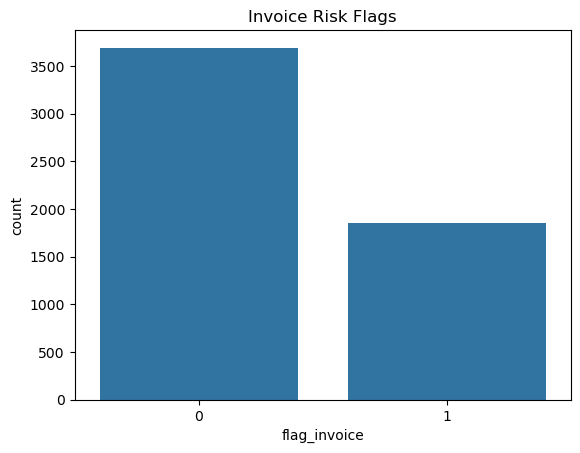

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="flag_invoice", data=merged_df)
plt.title("Invoice Risk Flags")
plt.show()

In [57]:
merged_df.corr()

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,invoice_quantity,invoice_dollars,Freight,days_to_po_invoice,days_to_pay,flag_invoice
PONumber,1.000000,0.013423,0.049442,0.059221,-0.042362,0.049230,0.058917,0.043617,-0.002234,0.012045,0.564946
total_brands,0.013423,1.000000,0.783825,0.753092,0.000496,0.566394,0.536952,0.536381,0.009519,0.026958,0.008961
total_item_quantity,0.049442,0.783825,1.000000,0.963831,-0.014016,0.706117,0.667666,0.656616,0.005543,0.020321,0.032783
total_item_dollars,0.059221,0.753092,0.963831,1.000000,-0.014251,0.668171,0.679537,0.670768,0.007931,0.021047,0.037994
avg_receiving_delay,-0.042362,0.000496,-0.014016,-0.014251,1.000000,0.000519,0.004694,0.015645,0.515538,0.261361,0.311667
invoice_quantity,0.049230,0.566394,0.706117,0.668171,0.000519,1.000000,0.963831,0.946550,0.000526,0.023920,0.032783
invoice_dollars,0.058917,0.536952,0.667666,0.679537,0.004694,0.963831,1.000000,0.985141,0.001610,0.028114,0.037994
Freight,0.043617,0.536381,0.656616,0.670768,0.015645,0.946550,0.985141,1.000000,0.003265,0.028897,0.037759
days_to_po_invoice,-0.002234,0.009519,0.005543,0.007931,0.515538,0.000526,0.001610,0.003265,1.000000,0.174757,0.183115
days_to_pay,0.012045,0.026958,0.020321,0.021047,0.261361,0.023920,0.028114,0.028897,0.174757,1.000000,0.098297


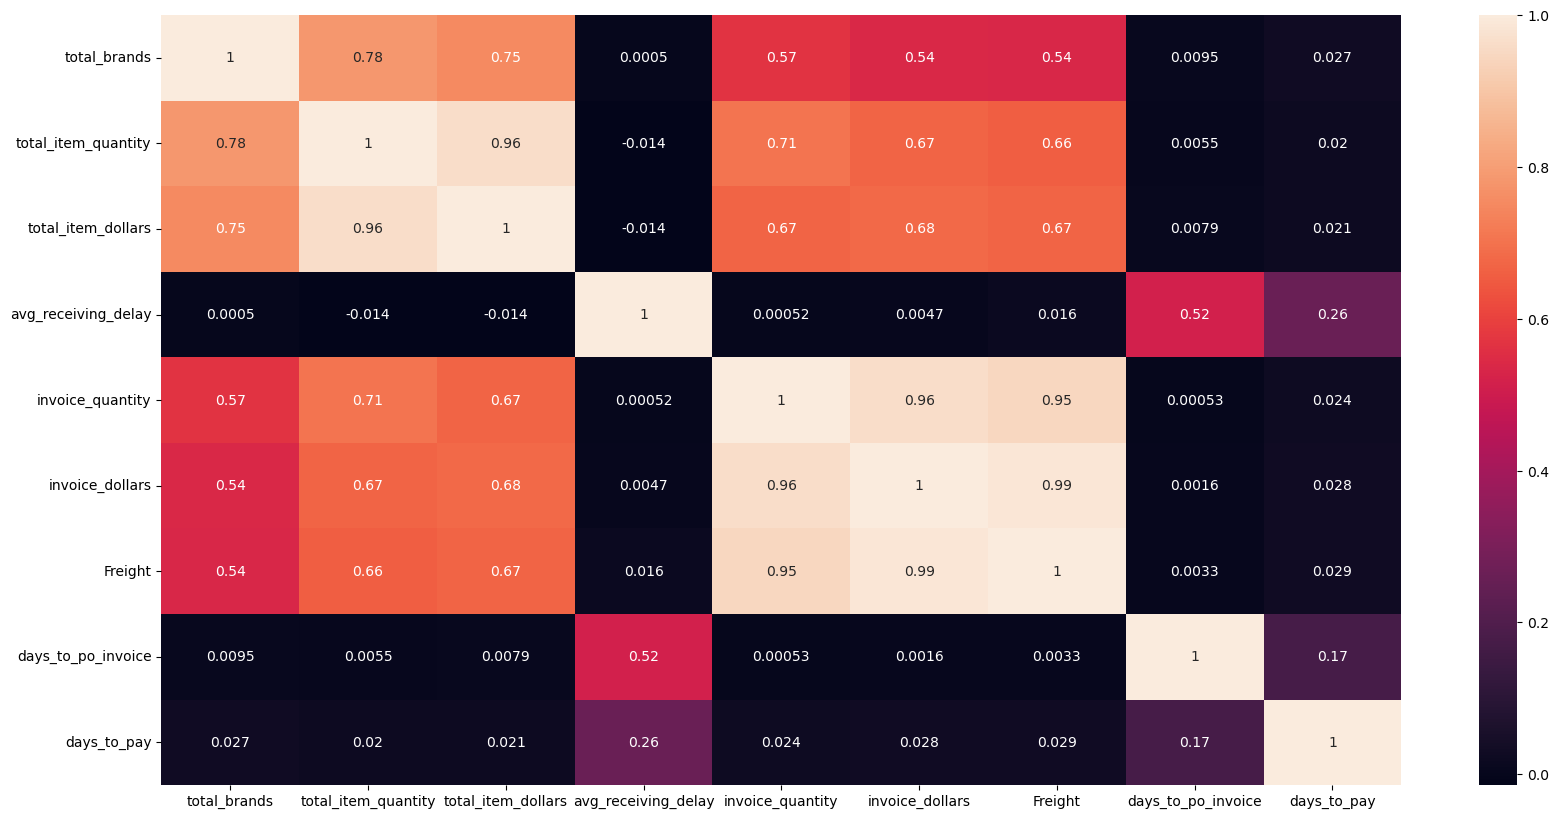

In [62]:
plt.figure(figsize =(20,10))
sns.heatmap(merged_df.iloc[:,1:-1].corr(),annot = True)
plt.show()

In [63]:
flagged = merged_df[merged_df['flag_invoice']==1]
normal = merged_df[merged_df['flag_invoice']==0]

In [64]:
significant_features = []
non_significant_features = []
results = []

In [71]:
metrics = ['invoice_quantity', 'invoice_dollars', 'Freight', 
           'days_to_po_invoice', 'days_to_pay', 'total_brands', 
           'total_item_quantity','total_item_dollars', 'avg_receiving_delay']

In [72]:
from scipy.stats import ttest_ind

for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value=ttest_ind(
    flagged[metric].dropna(),
    normal[metric].dropna(),
    equal_var = False
    )

    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
        "metric": metric,
        "flagged_mean": flagged_mean.round(2),
        "normal_mean": normal_mean.round(2),
        "p_value":p_value.round(3)
    })
    else:
        non_significant_features.append(metric)
        

In [74]:
non_significant_features

['total_brands']

In [75]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_to_po_invoice',
 'days_to_pay',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [79]:
X = merged_df[[ 'invoice_quantity',  'invoice_dollars', 'Freight', 'days_to_po_invoice','total_brands', 'total_item_quantity',
               'total_item_dollars','avg_receiving_delay']]

y = merged_df['flag_invoice']

In [80]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,days_to_po_invoice,total_brands,days_to_pay,total_item_quantity,total_item_dollars,avg_receiving_delay
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,16.0,41.0,52.0,6059.0,58073.0,8.0
std,14453.0,140234.0,714.0,3.0,77.0,6.0,14453.0,140234.0,2.0
min,1.0,4.0,0.0,9.0,1.0,40.0,1.0,4.0,3.0
25%,83.0,968.0,5.0,14.0,3.0,47.0,83.0,968.0,6.0
50%,423.0,4765.0,25.0,16.0,7.0,52.0,423.0,4765.0,8.0
75%,5100.0,44587.0,230.0,19.0,46.0,56.0,5100.0,44587.0,9.0
max,141660.0,1660436.0,8468.0,23.0,807.0,63.0,141660.0,1660436.0,13.0


In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   
)

In [85]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)
X_test_scaled =  scaler.transform(X_test)

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [88]:
model1= LogisticRegression(random_state =42)
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state = 42)
model2.fit(X_train_scaled, y_train)

model3= RandomForestClassifier(random_state =42)
model3.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [91]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"\n📊 {model_name} Performance:")
    print("-" * 40)

    print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
    print("Precision:", round(precision_score(y_test, y_pred), 3))
    print("Recall:", round(recall_score(y_test, y_pred), 3))
    print("F1 Score:", round(f1_score(y_test, y_pred), 3))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

In [92]:
evaluate_model(model1,X_test_scaled, y_test, 'LogisticRegression')
evaluate_model(model2,X_test_scaled, y_test, 'Decision Tree Classifier')
evaluate_model(model3,X_test_scaled, y_test, 'Random Forest Classifier')


📊 LogisticRegression Performance:
----------------------------------------
Accuracy: 0.757
Precision: 0.763
Recall: 0.392
F1 Score: 0.518

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.94      0.84       739
           1       0.76      0.39      0.52       370

    accuracy                           0.76      1109
   macro avg       0.76      0.67      0.68      1109
weighted avg       0.76      0.76      0.73      1109

Confusion Matrix:
[[694  45]
 [225 145]]

📊 Decision Tree Classifier Performance:
----------------------------------------
Accuracy: 0.959
Precision: 0.948
Recall: 0.927
F1 Score: 0.937

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       739
           1       0.95      0.93      0.94       370

    accuracy                           0.96      1109
   macro avg       0.96      0.95      0.95      1109
weighted avg       0.96     

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   
)

In [95]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled  = scaler.fit_transform(X_train)
X_test_scaled =  scaler.transform(X_test)

In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [97]:
model1= LogisticRegression(random_state =42)
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state = 42)
model2.fit(X_train_scaled, y_train)

model3= RandomForestClassifier(random_state =42)
model3.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric